# TF-IDF & BoW models

**Dataset :** https://www.kaggle.com/competitions/nlp-getting-started/data

In [ ]:
import pandas as pd

train_data = pd.read_csv('/content/train.csv')
test_data = pd.read_csv('/content/test.csv')

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\d', ' ', text)
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing to the training and test data
train_data['processed_text'] = train_data['text'].apply(preprocess_text)
test_data['processed_text'] = test_data['text'].apply(preprocess_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


**Why did I choose particular tokenizer/stemmer** :

*  I've used NLTK's word tokenizer because it is a reliable tokenizer that splits text into words based on English language rules and also it handles punctuation and contractions well.

*   I've used NLTK's Stopwords which removes unnecessary words which don't have specific meaning and by removing it I can reduce noise in the data.

*   I've applied NLTK's lematizer which reduces words to their base form and preserves the meaning.


**TF-IDF Vectorizer :** It is used to convert text into weighted numerical features, capturing the importance of words across documents.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_data['processed_text'])

X_test_tfidf = tfidf_vectorizer.transform(test_data['processed_text'])

**Bag-of-Words (BoW) Vectorization :** In this process, it creates a vocabulary of unique words in the dataset and it is mainly used to convert text into a matrix of token (word) counts

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(train_data['processed_text'])

X_test_bow = bow_vectorizer.transform(test_data['processed_text'])

**Applying Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

log_reg = LogisticRegression()

# Hyperparameter tuning using GridSearchCV
param_grid = {'C': [0.01, 0.1, 1, 10]}
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy')

# Fit the model on TF-IDF features
grid_search.fit(X_train_tfidf, train_data['target'])
best_log_reg_tfidf = grid_search.best_estimator_
y_pred_tfidf = best_log_reg_tfidf.predict(X_test_tfidf)

# Fit the model on BoW features
grid_search.fit(X_train_bow, train_data['target'])
best_log_reg_bow = grid_search.best_estimator_
y_pred_bow = best_log_reg_bow.predict(X_test_bow)

**Applying SVM Model**

In [ ]:
from sklearn.svm import SVC

svm = SVC()

# Hyperparameter tuning using GridSearchCV
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')

# Fit the model on TF-IDF features
grid_search.fit(X_train_tfidf, train_data['target'])
best_svm_tfidf = grid_search.best_estimator_
y_pred_tfidf_svm = best_svm_tfidf.predict(X_test_tfidf)

# Fit the model on BoW features
grid_search.fit(X_train_bow, train_data['target'])
best_svm_bow = grid_search.best_estimator_
y_pred_bow_svm = best_svm_bow.predict(X_test_bow)

In [ ]:
from sklearn.model_selection import train_test_split

# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_tfidf, train_data['target'], test_size=0.2, random_state=42)

# Train and evaluate Logistic Regression
log_reg.fit(X_train, y_train)
y_val_pred = log_reg.predict(X_val)
accuracy = accuracy_score(y_val, y_val_pred)
print(f'Logistic Regression Accuracy: {accuracy}')

# Train and evaluate SVM
svm.fit(X_train, y_train)
y_val_pred_svm = svm.predict(X_val)
accuracy_svm = accuracy_score(y_val, y_val_pred_svm)
print(f'SVM Accuracy: {accuracy_svm}')

Logistic Regression Accuracy: 0.7971109652002626
SVM Accuracy: 0.7977675640183848


**Observations**

* Logistic Regression: Achieved an accuracy of ~79.71%.

* SVM: Achieved an accuracy of ~79.78%.

* Both models performed similarly, with SVM slightly outperforming Logistic Regression by 0.06%.
* Both Logistic Regression and SVM are effective baseline models for text classification tasks, achieving ~79.7% accuracy.

In [ ]:
# Prepare submission file for Logistic Regression with TF-IDF
submission = pd.DataFrame({'id': test_data['id'], 'target': y_pred_tfidf})
submission.to_csv('submission_log_reg_tfidf.csv', index=False)

# Prepare submission file for SVM with TF-IDF
submission_svm = pd.DataFrame({'id': test_data['id'], 'target': y_pred_tfidf_svm})
submission_svm.to_csv('submission_svm_tfidf.csv', index=False)

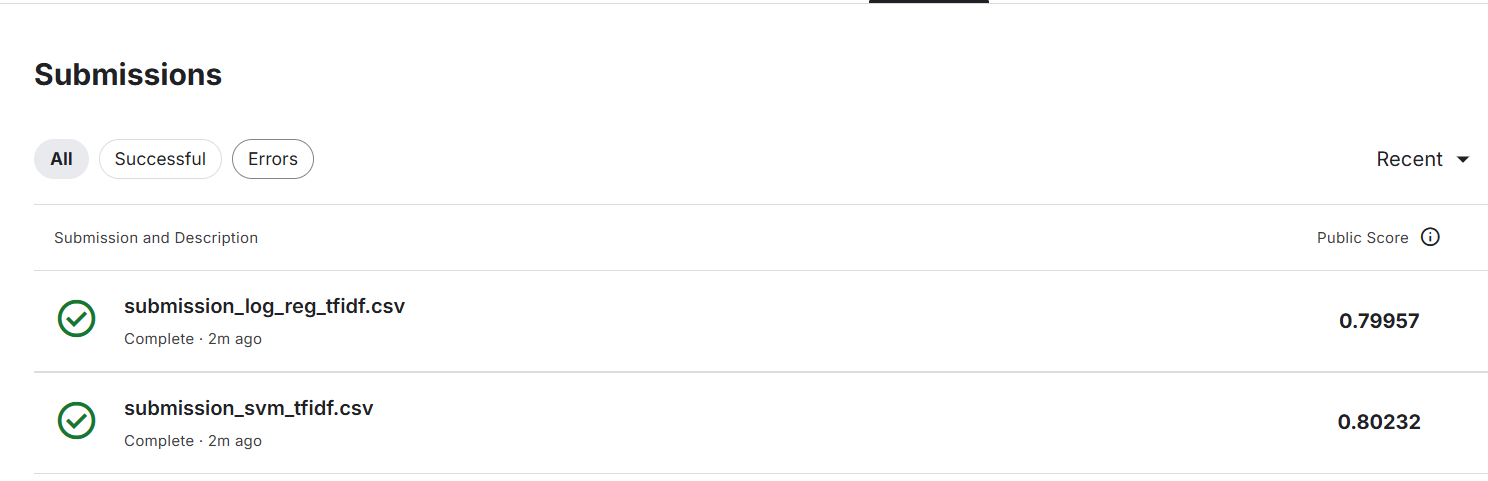

# Neural Networks based Models

**Choose the Architecture :** For text classification, LSTM (Long Short-Term Memory) is a popular choice because it can capture long-term dependencies in sequential data like text. Compared to simple RNNs, LSTMs are better at avoiding the vanishing gradient problem, making them more effective for longer sequences.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize the text data
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_data['processed_text'])

# Convert text to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(train_data['processed_text'])
X_test_seq = tokenizer.texts_to_sequences(test_data['processed_text'])

# Pad sequences to ensure uniform input size
max_len = 100  # Maximum sequence length
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

# Prepare labels
y_train = train_data['target']

**Why LSTM?**


*   Sequential Data: Text is inherently sequential, and LSTMs are designed to handle such data.
*   Long-Term Dependencies: LSTMs can remember information over long sequences, which is useful for understanding context in sentences.
*   Flexibility: LSTMs can be combined with embeddings to improve performance.

**Build the LSTM Model :**  We will use TensorFlow/Keras to build the LSTM model. The architecture includes:

1. Embedding Layer: Converts integer tokens into dense vectors of fixed size.
2. LSTM Layer: Processes the sequential data.
3. Dense Layer: Outputs the final classification.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Define the model
model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=max_len),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Train the Model :** Train the model on the training data and validate it on a validation set.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_pad, y_train, test_size=0.2, random_state=42)

# Train the model
history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=10,  # Number of epochs
    batch_size=64  # Batch size
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 45s 400ms/step - accuracy: 0.5583 - loss: 0.6877 - val_accuracy: 0.5739 - val_loss: 0.6827
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 40s 387ms/step - accuracy: 0.5673 - loss: 0.6832 - val_accuracy: 0.5739 - val_loss: 0.6822
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 36s 374ms/step - accuracy: 0.5606 - loss: 0.6863 - val_accuracy: 0.5739 - val_loss: 0.6832
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 42s 385ms/step - accuracy: 0.5631 - loss: 0.6885 - val_accuracy: 0.5739 - val_loss: 0.6826
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 378ms/step - accuracy: 0.5640 - loss: 0.6862 - val_accuracy: 0.5739 - val_loss: 0.6828
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 388ms/step - accuracy: 0.5621 - loss: 0.6857 - val_accuracy: 0.5739 - val_loss: 0.6834
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 384ms/step - accuracy: 0.5607 - loss: 0.6868 - val_accuracy: 0.5739 - val_loss: 0.6824
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 384ms/step - accuracy: 0.5701 - loss: 0.6839 - val_accu

**Tune Hyperparameters :** To improve the model, experiment with different LSTM layers

In [ ]:
# Experiment with a larger embedding size and more LSTM units
model_tuned = Sequential([
    Embedding(input_dim=10000, output_dim=256, input_length=max_len),
    LSTM(256, dropout=0.3, recurrent_dropout=0.3, return_sequences=True),  # First LSTM layer
    LSTM(128, dropout=0.3, recurrent_dropout=0.3),  # Second LSTM layer
    Dense(64, activation='relu'),
    Dropout(0.6),
    Dense(1, activation='sigmoid')
])

# Compile the model
model_tuned.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the tuned model
history_tuned = model_tuned.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy: 0.5520 - loss: 0.6896 - val_accuracy: 0.5739 - val_loss: 0.6853
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - accuracy: 0.5550 - loss: 0.6895 - val_accuracy: 0.5739 - val_loss: 0.6824
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.5676 - loss: 0.6857 - val_accuracy: 0.5739 - val_loss: 0.6831
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.5651 - loss: 0.6857 - val_accuracy: 0.5739 - val_loss: 0.6825
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.5585 - loss: 0.6869 - val_accuracy: 0.5739 - val_loss: 0.6825
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.5702 - loss: 0.6841 - val_accuracy: 0.5739 - val_loss: 0.6823
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.5702 - loss: 0.6855 - val_accuracy: 0.5739 - val_loss: 0.6822
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.5730 - loss: 0.6849 - val_accu

**Evaluate the Model :** Evaluate the model on the validation set and check for overfitting.

In [ ]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model_tuned.evaluate(X_val, y_val)
print(f'Validation Loss: {val_loss}')
print(f'Validation Accuracy: {val_accuracy}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 288ms/step - accuracy: 0.5694 - loss: 0.6835
Validation Loss: 0.6821996569633484
Validation Accuracy: 0.5738673806190491


**Make Predictions and Submit :** Submit the best model

In [ ]:
# Make predictions on the test data
y_pred_prob = model_tuned.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

# Prepare submission file
submission = pd.DataFrame({'id': test_data['id'], 'target': y_pred.flatten()})
submission.to_csv('submission_lstm.csv', index=False)

102/102 ━━━━━━━━━━━━━━━━━━━━ 30s 287ms/step


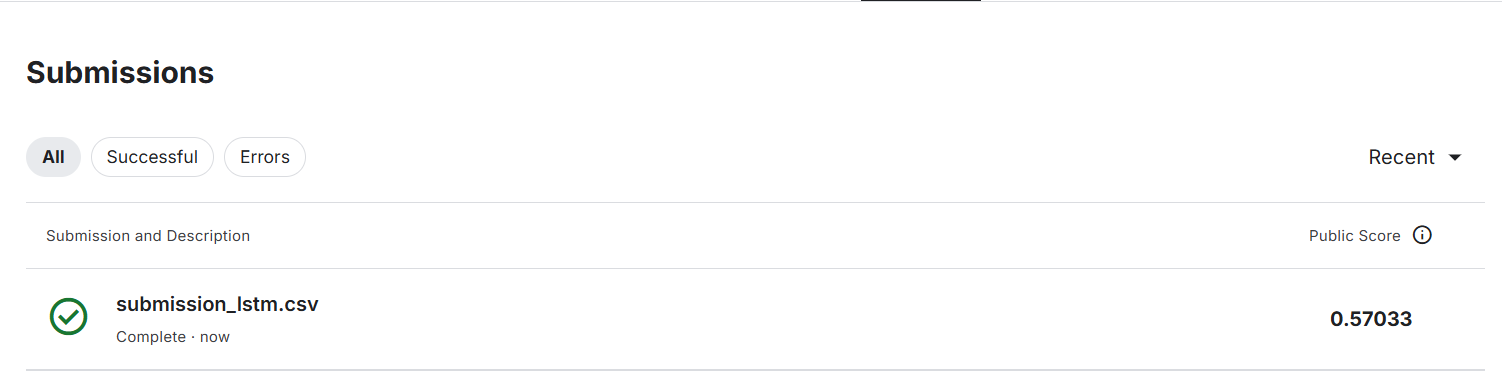

**Key Observations**


*   **Validation Accuracy (57.39%):** The model's accuracy on the validation set is only 57.39%, which is slightly better than random guessing (50% for binary classification). This suggests that the model is not effectively learning the patterns in the data.

*   **Validation Loss (0.6826):** The loss value is relatively high, indicating that the model's predictions are far from the true labels. This further confirms that the model is underperforming.
*   **Training Accuracy (56.94%):** The training accuracy is also low, which suggests that the model is not fitting the training data well. This could be due to insufficient model capacity, poor hyperparameter choices, or inadequate preprocessing.

**Conclusion :**

Based on the results, Logistic Regression and SVM outperformed the Neural Network (LSTM) model for this text classification task.

*   Logistic Regression and SVM models achieved high validation accuracy (~79.8%), making them strong baselines for this task. They are computationally efficient and work well with traditional text representations like TF-IDF or BoW. SVM performed slightly better than Logistic Regression, but the difference is minimal.
*   The LSTM model underperformed significantly, with a validation accuracy of only 57.39%.

# Fine-tune pre-trained model (it may be from torch/transformers, etc.)

In [ ]:
pip install torch transformers datasets pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**Data Loading and Preprocessing:** Preprocesses the text data by converting it to lowercase, removing special characters and numbers, and normalizing spaces.

**Data Splitting:** Splits the training data into training and validation sets (80% training, 20% validation) for model evaluation and tuning.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
train_data = pd.read_csv('/content/train.csv')
test_data = pd.read_csv('/content/test.csv')

# Preprocess the text data
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    text = re.sub(r'\d', ' ', text)  # Remove numbers
    text = re.sub(r'\s+', ' ', text)  # Replace multiple spaces with a single space
    return text

train_data['processed_text'] = train_data['text'].apply(preprocess_text)
test_data['processed_text'] = test_data['text'].apply(preprocess_text)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(train_data['processed_text'], train_data['target'], test_size=0.2, random_state=42)



---



**Tokenization:** Loads the DistilBertTokenizer for tokenizing text data into input IDs and attention masks. Tokenizes the training, validation, and test datasets, ensuring all sequences are truncated or padded to a maximum length of 128 tokens.

**Preparation for Model Input:** Converts raw text data into a format suitable for input into a DistilBERT model, enabling efficient processing during training and evaluation.

In [ ]:
from transformers import DistilBertTokenizer

# Load the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Tokenize the training and validation data
train_encodings = tokenizer(X_train.tolist(), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(X_val.tolist(), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_data['processed_text'].tolist(), truncation=True, padding=True, max_length=128)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]



---



**Custom Dataset Creation:** Defined a custom PyTorch Dataset class (DisasterTweetsDataset) to handle tokenized text data and labels and Converted tokenized encodings (input IDs, attention masks) and labels into PyTorch tensors for model input.

**Data Preparation for Training:** Created training, validation, and test datasets using the custom Dataset class, enabling seamless integration with PyTorch's DataLoader for efficient batch processing during model training and evaluation.

In [ ]:
import torch
from torch.utils.data import Dataset

class DisasterTweetsDataset(Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

# Create datasets
train_dataset = DisasterTweetsDataset(train_encodings, y_train.tolist())
val_dataset = DisasterTweetsDataset(val_encodings, y_val.tolist())
test_dataset = DisasterTweetsDataset(test_encodings)



---



**Chosen Model: DistilBERT**

**Why did I choose DistilBERT?**

DistilBERT is a smaller, faster, and lighter version of BERT (Bidirectional Encoder Representations from Transformers).


*   Efficiency: Faster training and inference compared to BERT, without significant loss in performance.
*   Effectiveness: Performs well on text classification tasks, including binary classification like disaster tweet detection.
*   Ease of Use: Integrated into the Hugging Face transformers library, making it easy to fine-tune and deploy.
*   Fine Tuneing: The model is fine-tuned on the disaster tweets dataset using the Hugging Face Trainer API, enabling efficient training and evaluation.


**Steps of impletation of the model:**

*   **Model Initialization and Training Setup:**
 *   Loads a pre-trained DistilBertForSequenceClassification model for binary text classification.

 *   Defines a compute_metrics function to calculate accuracy during evaluation.

*   **Training Configuration:**
 *   Sets up training arguments (TrainingArguments) such as learning rate, batch size, number of epochs, and evaluation strategy.

 * Initializes the Trainer class with the model, datasets, and metrics for fine-tuning.

* **Model Fine-Tuning:**

 *   Fine-tunes the DistilBERT model on the training dataset while evaluating performance on the validation set using the defined metrics.

In [ ]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score
import numpy as np

# Define compute_metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)  # Convert logits to class predictions
    return {'accuracy': accuracy_score(labels, predictions)}

# Load the pre-trained model
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy='epoch',
    logging_dir='./logs',
    logging_steps=10,
    load_best_model_at_end=True,
    report_to="none"
)

# Define the Trainer with compute_metrics
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics

# Fine-tune the model
trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.304500,0.387939,0.839133
2,0.284800,0.397646,0.843073
3,0.316800,0.432734,0.843073


TrainOutput(global_step=1143, training_loss=0.3432679155471548, metrics={'train_runtime': 5597.9453, 'train_samples_per_second': 3.264, 'train_steps_per_second': 0.204, 'total_flos': 231618729099240.0, 'train_loss': 0.3432679155471548, 'epoch': 3.0})

**Key Observations**

*  The model achieved high accuracy (84.3%) on the validation set, demonstrating its ability to classify disaster-related tweets effectively.
*  The slight increase in validation loss indicates potential overfitting, which could be addressed with some techniques.




---



In [ ]:
# Evaluate the model
results = trainer.evaluate()
print(f"Validation Loss: {results['eval_loss']}")
print(f"Validation Accuracy: {results['eval_accuracy']}")

Validation Loss: 0.3879394233226776
Validation Accuracy: 0.8391332895600788


In [ ]:
# Make predictions on the test data
test_predictions = trainer.predict(test_dataset)
y_pred = torch.argmax(torch.tensor(test_predictions.predictions), dim=1).numpy()

# Prepare submission file
submission = pd.DataFrame({'id': test_data['id'], 'target': y_pred})
submission.to_csv('submission_distilbert.csv', index=False)

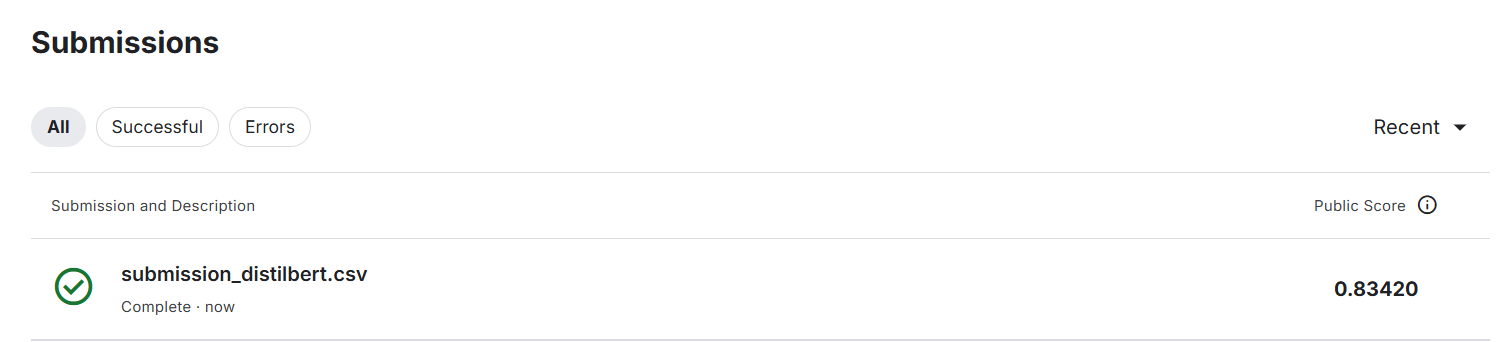

**Final Observations**

*   The fine-tuned DistilBERT model performed well, achieving 83.4% accuracy on Kaggle.
*   It is a lightweight and efficient model suitable for text classification tasks like disaster tweet detection.

# Conclusion

**Which Model Was the Best in Terms of Quality/Resources?**


*  **Best Model: DistilBERT.**

   *  Quality: Achieved ~84.3% validation accuracy, which is significantly better than the baseline models (Logistic Regression: 79.78%, SVM: 79.84%).
   *  Resources: DistilBERT is 40% smaller and 60% faster than BERT, making it a good balance between performance and computational efficiency.


*  Comparison:

 *  Logistic Regression and SVM: Simpler and faster to train but achieved lower accuracy (~79.8%).
 *   LSTM with GloVe: Less accurate (~57.4%) and slower compared to DistilBERT.






---



**How Can the Achieved Results Be Improved?**

**Model Improvements:**

*  We can Use a larger pre-trained model like BERT, RoBERTa, or ALBERT for potentially better accuracy.
*   We can fine-tune hyperparameters (e.g., learning rate, batch size, number of epochs) to optimize performance.
* We can use ensemble methods to combine predictions from multiple models.

**Data Improvements:**

*  Perform data augmentation to increase the diversity of the training data.
*  Clean and preprocess the text data further (e.g., handle misspellings, remove rare words).

**Training Improvements:**

* Use early stopping to prevent overfitting.

* Increase the number of epochs or use a learning rate scheduler for better convergence.



---



**What Difficulties Were Met?**

**Data Preprocessing:** Handling noisy text data (e.g., special characters, hashtags, emojis) required careful preprocessing.

**Model Training:**

* Overfitting: The validation loss increased slightly in later epochs, indicating potential overfitting.

* Resource Constraints: Training Transformer-based models like DistilBERT requires significant computational resources (e.g., GPU).

**Evaluation:** Lack of true labels for the test data made it impossible to evaluate the model's performance directly on the test set without submitting to Kaggle.

**Hyperparameter Tuning:** Finding the optimal set of hyperparameters (e.g., learning rate, batch size) required multiple experiments.

